In [ ]:
#| default_exp segmask.core

# SegMaskCore

> API details.

In [ ]:
#|hide
from nbdev.showdoc import *

In [ ]:
#| export
from fastcore.all import *
import cv2
import numpy as np
import polvo as pv

/home/lgvaz/git/polvo/polvo/utils/logging.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [ ]:
#|export
# To test, do a mask to_polygons and from_polygons
class Polygon:
    def __init__(self, points):
        self.points = np.array(points)
    def __repr__(self): return f"<{self.__class__.__name__} ({self.points})>"
        
    @property
    def xy(self): return self.points
        
    @classmethod
    def from_xy(cls, points): return cls(points)
    @classmethod
    def from_flat(cls, points): return cls(np.reshape(points, (-1, 2)))

In [ ]:
#|export
class PolygonLabeled(GetAttr):
    _default='polygon'
    def __init__(self, polygon, label): store_attr()
    def __repr__(self): return f'{self.label} | {self.polygon}'

In [ ]:
polygons = [
    PolygonLabeled(Polygon.from_xy([(100, 100), (200, 100), (200, 200), (100, 200)]), pv.Label(1, 'test-1')), # Square
    PolygonLabeled(Polygon.from_flat([300, 300, 350, 320, 320, 380]), pv.Label(3, 'test-3')),                 # Triangle
    PolygonLabeled(Polygon.from_flat([30, 30, 400, 100, 300, 280, 370, 120]), pv.Label(1, 'test-1')),          
]

In [ ]:
#|export
class SegMask:
    def __init__(self, mask, class_map):
        self.mask = mask
        self.class_map = class_map
       
    def accept_visit(self, visitor): return visitor.visit_segmask(self)
    def show(self): return pv.show_image(self.mask)
    
    # TODO: Refactor to_contours, most of it's logic is the same as `to_polygons`.
    # Maybe we can substitue it completely for to_polygons and update it's uses accordingly (COCOExporter)
    def to_contours(self, method=cv2.CHAIN_APPROX_SIMPLE, mode=cv2.RETR_EXTERNAL):
        arr = self.mask.squeeze().astype(np.uint8)
        contours = {}
        for id_ in set(np.unique(arr)):
            label = self.class_map.id2name[id_]
            if label == 'background': continue
            mask = (arr == id_).astype(np.uint8)
            contours[label] = cv2.findContours(mask, mode, method)[0]
        return contours
    
    def to_polygons(self, method=cv2.CHAIN_APPROX_SIMPLE, mode=cv2.RETR_EXTERNAL):
        arr = self.mask.squeeze().astype(np.uint8)
        polygons = []
        for id_ in set(np.unique(arr)):
            label = self.class_map.id2label[id_]
            if label.name == 'background': continue
            mask = (arr == id_).astype(np.uint8)
            for contour in cv2.findContours(mask, mode, method)[0]:
                polygon = Polygon.from_flat(contour.flatten())
                polygons.append(PolygonLabeled(polygon, label))
        return polygons
    
    @classmethod
    def from_polygons(cls, polygons: Sequence[PolygonLabeled], width, height, background_id=0):
        mask_arr = np.zeros((height, width), dtype=np.uint8)
        labels = set((pv.Label(background_id, 'background'),))
        for poly in polygons:
            labels.add(poly.label)
            points = poly.xy.astype(np.int32)
            points = points.reshape((-1, 1, 2))  # Required shape for fillPoly
            cv2.fillPoly(mask_arr, [points], color=poly.label.id)
        return cls(mask_arr, pv.ClassMap(*labels))

    def __repr__(self):
        return f"<{self.__class__.__name__}\n{self.mask}>"

<AxesSubplot:>

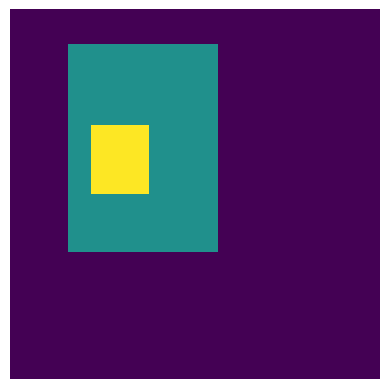

In [ ]:
mask = np.zeros((32, 32))
mask[3:21, 5:18] = 1
mask[10:16, 7:12] = 2
mask = SegMask(mask, pv.ClassMap(pv.Label(0, 'background'), pv.Label(1, 'test'), pv.Label(2, 'test2')))
mask.show()

<AxesSubplot:>

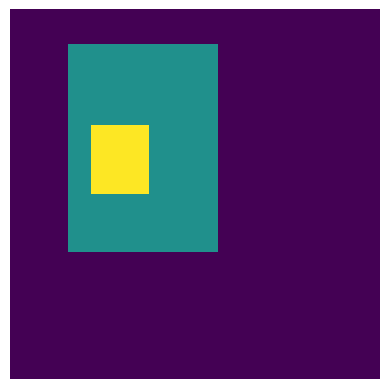

In [ ]:
SegMask.from_polygons(mask.to_polygons(), 32, 32).show()

<AxesSubplot:>

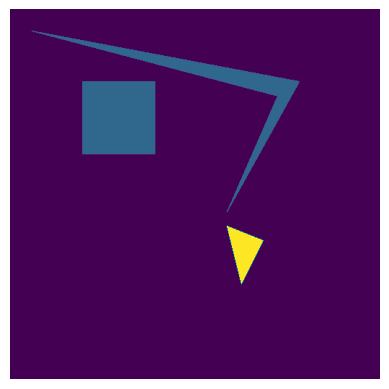

In [ ]:
mask = SegMask.from_polygons(polygons, 512, 512)
mask.show()

<AxesSubplot:>

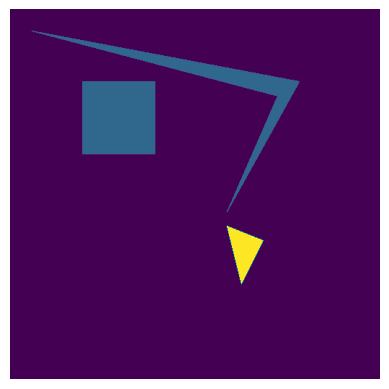

In [ ]:
SegMask.from_polygons(mask.to_polygons(), 512, 512).show()

In [ ]:
#| hide
from nbdev import nbdev_export
nbdev_export()